# Unit 4 code companion: Estimation, Likelihood, and the Bootstrap

Score estimators against a truth you control, watch a likelihood sharpen as data arrives, and build confidence intervals for statistics that have no formula.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. The estimator contest

The serial-number problem: N items numbered 1..N, you see n of them, estimate N. Three rules, scored by how they behave across many samples.

In [2]:
N_TRUE, n, reps = 500, 8, 20_000
samples = np.array([rng.choice(np.arange(1, N_TRUE+1), size=n, replace=False)
                    for _ in range(reps)])

estimators = {
    "largest seen":          samples.max(axis=1),
    "2*mean - 1":            2*samples.mean(axis=1) - 1,
    "max*(n+1)/n - 1":       samples.max(axis=1)*(n+1)/n - 1,
}

print(f"truth N = {N_TRUE}, sample size n = {n}\n")
print(f"{'estimator':>18} {'bias':>8} {'SD':>8} {'RMSE':>8}")
for name, est in estimators.items():
    bias = est.mean() - N_TRUE
    rmse = np.sqrt(((est - N_TRUE)**2).mean())
    print(f"{name:>18} {bias:>8.1f} {est.std():>8.1f} {rmse:>8.1f}")

truth N = 500, sample size n = 8

         estimator     bias       SD     RMSE
      largest seen    -54.5     49.0     73.3
        2*mean - 1      0.7    101.0    101.0
   max*(n+1)/n - 1      0.2     55.1     55.1


Notice the ranking. 'Largest seen' has the worst bias but not the worst RMSE. '2*mean-1' is perfectly unbiased and still loses, because it is so variable. **Unbiased is not the same as accurate**, and RMSE is the column that matters when you only get one sample.

## 2. Bias, variance, and why shrinkage wins

Estimating a rate for a group with very little data. Pull the estimate toward a sensible prior and watch the total error fall.

In [3]:
true_rate, prior_guess, n_obs, reps = 0.35, 0.20, 12, 40_000
raw = rng.binomial(n_obs, true_rate, reps) / n_obs

weights = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for w in weights:
    est = (1-w)*raw + w*prior_guess
    rows.append((w, est.mean()-true_rate, est.std(), np.sqrt(((est-true_rate)**2).mean())))
best_w = min(rows, key=lambda r: r[3])[0]

print(f"{'shrink toward prior':>20} {'bias':>8} {'SD':>8} {'RMSE':>8}")
for w, bias, sd, rmse in rows:
    print(f"{w:>20.1f} {bias:>8.3f} {sd:>8.3f} {rmse:>8.3f}"
          + ("  <-- lowest total error" if w == best_w else ""))

 shrink toward prior     bias       SD     RMSE
                 0.0   -0.000    0.138    0.138
                 0.2   -0.030    0.110    0.114
                 0.4   -0.060    0.083    0.102  <-- lowest total error
                 0.6   -0.090    0.055    0.106
                 0.8   -0.120    0.028    0.123
                 1.0   -0.150    0.000    0.150


Shrinking a little makes the estimate *biased on purpose* and still lowers total error. This is the same trade that justifies regularization later in the course.

## 3. Likelihood: same estimate, different confidence



   3 of    10:  p-hat = 0.30,  SE = 0.1449
  30 of   100:  p-hat = 0.30,  SE = 0.0458
 300 of  1000:  p-hat = 0.30,  SE = 0.0145


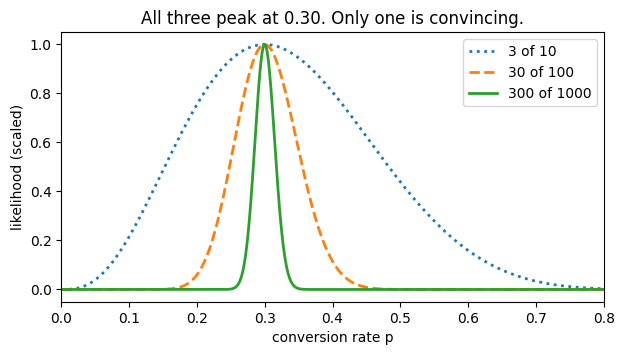

In [4]:
p = np.linspace(0.001, 0.999, 800)
for k, n_trials, style in [(3, 10, ":"), (30, 100, "--"), (300, 1000, "-")]:
    loglik = k*np.log(p) + (n_trials-k)*np.log(1-p)
    lik = np.exp(loglik - loglik.max())
    plt.plot(p, lik, style, lw=2, label=f"{k} of {n_trials}")
    se = np.sqrt((k/n_trials)*(1-k/n_trials)/n_trials)
    print(f"{k:>4} of {n_trials:>5}:  p-hat = {k/n_trials:.2f},  SE = {se:.4f}")
plt.xlim(0, 0.8); plt.xlabel("conversion rate p"); plt.ylabel("likelihood (scaled)")
plt.legend(); plt.title("All three peak at 0.30. Only one is convincing."); plt.show()

The width of the peak *is* the standard error, and the numbers confirm it: each tenfold increase in data narrows the curve by about a factor of three, matching the sqrt(n) rule. When software prints a huge standard error, it is telling you this curve is flat.

## 4. The bootstrap, on real data

Medical charges. We want intervals for a mean, a median, and a 90th percentile. Only one of those has a formula anyone remembers.

In [5]:
ins = pd.read_csv("https://richardson.byu.edu/220/insurance_all.csv")
charges = ins["charges"].values

def boot(x, stat, B=5000):
    idx = rng.integers(0, len(x), size=(B, len(x)))
    return stat(x[idx], axis=1)

for name, stat in [("mean", np.mean), ("median", np.median),
                   ("90th pct", lambda a, axis: np.percentile(a, 90, axis=axis))]:
    b = boot(charges, stat)
    lo, hi = np.percentile(b, [2.5, 97.5])
    print(f"{name:>10}: estimate {stat(charges[None, :], axis=1)[0]:9,.0f}   "
          f"SE {b.std():7,.0f}   95% CI [{lo:8,.0f}, {hi:8,.0f}]")

      mean: estimate    13,270   SE     336   95% CI [  12,613,   13,928]


    median: estimate     9,382   SE     280   95% CI [   8,811,    9,874]
  90th pct: estimate    34,832   SE   1,378   95% CI [  30,482,   36,950]


In [6]:
# Sanity check: for the mean, the bootstrap should agree with the textbook formula.
b = boot(charges, np.mean)
print(f"bootstrap SE of the mean : {b.std():,.1f}")
print(f"formula  s/sqrt(n)       : {charges.std(ddof=1)/np.sqrt(len(charges)):,.1f}")

bootstrap SE of the mean : 325.7
formula  s/sqrt(n)       : 331.1


## 5. Where the bootstrap breaks

It can only reshuffle values you already saw, so it cannot see past the largest one.

true maximum of the distribution : 100.0
largest value in the sample      : 97.9
bootstrap 95% CI for the maximum : [95.5, 97.9]  <-- cannot exceed the sample max


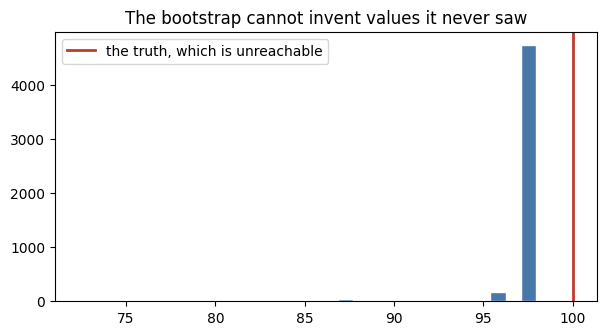

In [7]:
x = rng.uniform(0, 100, 60)
bmax = boot(x, np.max)
print(f"true maximum of the distribution : 100.0")
print(f"largest value in the sample      : {x.max():.1f}")
print(f"bootstrap 95% CI for the maximum : [{np.percentile(bmax, 2.5):.1f}, "
      f"{np.percentile(bmax, 97.5):.1f}]  <-- cannot exceed the sample max")

plt.hist(bmax, bins=30, color="#4878a8", edgecolor="white")
plt.axvline(100, color="#c0392b", lw=2, label="the truth, which is unreachable")
plt.legend(); plt.title("The bootstrap cannot invent values it never saw"); plt.show()

## 6. Resampling the right unit

The most common bootstrap error in industry, with the damage measured.

In [8]:
# 60 customers, 40 sessions each. Customers differ; sessions within a customer are alike.
n_cust, per_cust = 60, 40
cust_mean = rng.normal(30, 8, n_cust)
sessions = rng.normal(cust_mean[:, None], 3, size=(n_cust, per_cust))
flat = sessions.ravel()

wrong = boot(flat, np.mean)                       # resample sessions: WRONG
cust_means = sessions.mean(axis=1)
right = boot(cust_means, np.mean)                 # resample customers: RIGHT

print(f"resampling {len(flat):,} sessions : SE = {wrong.std():.3f}")
print(f"resampling {n_cust} customers    : SE = {right.std():.3f}")
print(f"\nthe wrong unit understates the uncertainty by {right.std()/wrong.std():.1f}x")

resampling 2,400 sessions : SE = 0.173
resampling 60 customers    : SE = 1.019

the wrong unit understates the uncertainty by 5.9x
